# Semantic Entropy for Uncertainty Quantification in LLM Outputs

**Sheroz Khan** | iRisk Lab, UIUC | Fall 2026

**Paper:** Farquhar, S., Kossen, J., Kuhn, L., and Gal, Y. (2024). "Detecting Hallucinations in Large Language Models Using Semantic Entropy." *Nature*, 630, 625-630. https://doi.org/10.1038/s41586-024-07421-0

(Earlier version: Kuhn, Gal, and Farquhar, ICLR 2023, arXiv:2302.09664. Same method; the Nature version is the extended, final publication.)

---

# Week 1: Paper Study and Proof-of-Concept Implementation

**Goal:** Understand the mathematical formulation of semantic entropy, implement the full pipeline (NLI clustering, discrete entropy), and verify on a pilot set of easy factoid questions.

## Research Question

Can semantic entropy, which measures uncertainty over meaning clusters rather than token sequences, reliably distinguish correct from incorrect LLM outputs on factual questions?

This notebook implements the semantic entropy pipeline from Farquhar et al. (*Nature*, 2024) from scratch and evaluates it on a pilot set of questions using a local LLM via Ollama.

## Motivation

Standard token-level uncertainty (e.g., predictive entropy over the next-token distribution) conflates two sources of variation:

1. **Semantic uncertainty:** the model is unsure *what* to say (different meanings).
2. **Lexical/syntactic uncertainty:** the model is unsure *how to phrase* a known answer.

For applications where the meaning of the output matters more than the exact wording, token-level entropy is misleading. The same correct answer phrased differently looks like disagreement to a token-level metric. Semantic entropy resolves this by clustering generations by meaning and computing entropy over those clusters.

**Example:** For the question "What is the capital of France?", the responses "Paris", "The capital is Paris", and "It's Paris" all mean the same thing. Token-level entropy sees three different strings and reports high uncertainty. Semantic entropy sees one meaning cluster and reports zero uncertainty.

## Paper Summary

**What the paper does:** Proposes semantic entropy as an uncertainty measure for LLM outputs. The method samples multiple generations, clusters them by semantic equivalence using a natural language inference (NLI) model, and computes Shannon entropy over the resulting cluster distribution.

**Key result:** High semantic entropy correlates with confabulation (the model generates confident-sounding but semantically inconsistent outputs) on TriviaQA, SQuAD, and BioASQ benchmarks. Outperforms token-level entropy, predictive entropy, and self-consistency baselines.

## Mathematical Formulation

### Step 1: Generation Probability (Equation 1)

Given input query $x$, each sampled generation $s = (t_1, t_2, \ldots, t_n)$ has probability under the standard autoregressive factorization:

$$p(s \mid x) = \prod_{i=1}^{n} p(t_i \mid t_{1:i-1}, x)$$

Each factor $p(t_i \mid t_{1:i-1}, x)$ is the softmax probability the LLM assigns to token $t_i$ given the query $x$ and all preceding tokens.

### Step 2: Semantic Clustering via Bidirectional NLI Entailment

Two generations $s_a$ and $s_b$ are defined as **semantically equivalent** if and only if:

$$s_a \Rightarrow s_b \quad \text{AND} \quad s_b \Rightarrow s_a$$

where $\Rightarrow$ denotes textual entailment as classified by a DeBERTa NLI model (trained on MNLI).

A **greedy algorithm** assigns each generation to clusters:
- For each generation $s_j$: check if it bidirectionally entails a representative of any existing cluster.
- If yes, assign $s_j$ to that cluster.
- If no, create a new cluster containing only $s_j$.

This produces $K$ clusters $(C_1, \ldots, C_K)$.

**Caveat:** Bidirectional NLI entailment is not a true equivalence relation. Entailment is not guaranteed to be transitive. The greedy algorithm is also order-dependent.

### Step 3: Cluster Probability

**Regular variant** (white-box, requires token probabilities):

$$p(C_k \mid x) = \sum_{s \in C_k} p(s \mid x)$$

In practice this is intractable (requires summing over all possible sequences in the cluster). The paper approximates by summing only over sampled generations.

**Discrete variant** (black-box compatible, what the paper mostly reports):

$$p(C_k \mid x) = \frac{1}{N} \sum_{j=1}^{N} \mathbb{1}[s_j \in C_k]$$

Simply the fraction of $N$ sampled generations in cluster $k$. Avoids sequence-length bias and does not require token probabilities.

### Step 4: Semantic Entropy (Equation 3)

Shannon entropy over the cluster distribution:

$$H_{\text{SE}}(x) = -\sum_{k=1}^{K} p(C_k \mid x) \cdot \log p(C_k \mid x)$$

**Interpretation:**
- $H_{\text{SE}} = 0$: all generations in one meaning cluster (semantically certain)
- $H_{\text{SE}} = \log K$: uniform spread across $K$ clusters (maximum uncertainty)

## What the Paper Claims vs. What It Actually Does

### Claim: "Detects hallucinations"
**Reality:** Flags high semantic entropy, which correlates with confabulation on short-form QA benchmarks. Does not verify whether any particular answer is correct. Measures semantic consistency across samples, not correctness.

### Claim: "Linguistic invariance"
**Reality:** The invariance comes from the NLI clustering step. Its quality depends entirely on DeBERTa-MNLI. If the NLI model fails to recognize two answers as equivalent, they get split into separate clusters and SE is inflated. Not tested on domain-specific text.

### Claim: "Outperforms predictive entropy"
**Reality:** On short-form factoid QA (TriviaQA, SQuAD, BioASQ) only. Long-form generation, numerical outputs, and multi-step reasoning are not evaluated.

### Approximations not emphasized in the paper
1. **N=10 samples.** Entropy estimate has high variance. Rare clusters can be missed.
2. **Greedy clustering is order-dependent.** Different sample orderings can produce different clusters.
3. **Discrete variant discards probability information.** A high-probability cluster and a low-probability cluster with equal sample counts get equal weight.

## Environment Setup

### Requirements
```bash
pip install transformers torch numpy pandas matplotlib requests
```

### Ollama Setup
This notebook uses a local LLM via [Ollama](https://ollama.com). Install Ollama and pull the model:
```bash
# Install Ollama (https://ollama.com/download)
# Then pull the model:
ollama pull gemma3:4b
```
Verify it is running:
```bash
ollama list
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import math
import json
import time
import warnings
warnings.filterwarnings('ignore')

print("Base packages loaded.")

Base packages loaded.


## Implementation: NLI Model

DeBERTa-large fine-tuned on MNLI, following Farquhar et al. (2024). Runs on CPU.

In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

NLI_MODEL_NAME = "microsoft/deberta-large-mnli"

nli_tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL_NAME)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL_NAME)
nli_model.eval()

NLI_LABELS = {0: "contradiction", 1: "neutral", 2: "entailment"}

print(f"NLI model loaded: {NLI_MODEL_NAME}")
print(f"Label mapping: {NLI_LABELS}")

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

[transformers] DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-large-mnli
Key    | Status     |  | 
-------+------------+--+-
config | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NLI model loaded: microsoft/deberta-large-mnli
Label mapping: {0: 'contradiction', 1: 'neutral', 2: 'entailment'}


## Implementation: Bidirectional Entailment Check

For two generations $s_a$ and $s_b$, check entailment in both directions. Semantically equivalent only if both directions yield "entailment." Question context is prepended to help the NLI model interpret short answers.

In [3]:
def check_entailment(premise: str, hypothesis: str) -> str:
    """Classify the NLI relation: entailment, contradiction, or neutral."""
    inputs = nli_tokenizer(
        premise, hypothesis,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )
    with torch.no_grad():
        logits = nli_model(**inputs).logits
    pred = logits.argmax(dim=-1).item()
    return NLI_LABELS[pred]


def are_semantically_equivalent(s_a: str, s_b: str, context: str = "") -> bool:
    """Bidirectional entailment check, following Farquhar et al. (2024)."""
    if context:
        s_a_ctx = f"Question: {context} Answer: {s_a}"
        s_b_ctx = f"Question: {context} Answer: {s_b}"
    else:
        s_a_ctx, s_b_ctx = s_a, s_b

    forward = check_entailment(s_a_ctx, s_b_ctx)
    backward = check_entailment(s_b_ctx, s_a_ctx)

    return (forward == "entailment") and (backward == "entailment")


# === Verification ===
print("--- Verification ---")
ctx = "What is the capital of France?"

pairs = [
    ("Paris", "The capital of France is Paris", True),
    ("Paris", "It's Paris", True),
    ("Paris", "London", False),
]

for a, b, expected in pairs:
    result = are_semantically_equivalent(a, b, context=ctx)
    status = "OK" if result == expected else "MISMATCH"
    print(f"  '{a}' vs '{b}': {result} (expected {expected}) [{status}]")

--- Verification ---
  'Paris' vs 'The capital of France is Paris': True (expected True) [OK]
  'Paris' vs 'It's Paris': True (expected True) [OK]
  'Paris' vs 'London': False (expected False) [OK]


## Implementation: Greedy Semantic Clustering

Greedy algorithm from the paper: each generation is compared against the representative (first member) of each existing cluster.

In [4]:
def cluster_by_meaning(generations: list, context: str = "") -> list:
    """
    Greedy semantic clustering via bidirectional NLI entailment.
    Returns: list of lists, each inner list is a semantic cluster.
    """
    clusters = []

    for gen in generations:
        assigned = False
        for cluster in clusters:
            representative = cluster[0]
            if are_semantically_equivalent(gen, representative, context):
                cluster.append(gen)
                assigned = True
                break

        if not assigned:
            clusters.append([gen])

    return clusters

## Implementation: Discrete Semantic Entropy

$$H_{\text{SE}}(x) = -\sum_{k=1}^{K} \frac{|C_k|}{N} \cdot \log \frac{|C_k|}{N}$$

In [5]:
def compute_semantic_entropy(clusters: list, n_total: int) -> float:
    """Discrete semantic entropy (Shannon entropy over cluster fractions, in nats)."""
    entropy = 0.0
    for cluster in clusters:
        p_k = len(cluster) / n_total
        if p_k > 0:
            entropy -= p_k * math.log(p_k)
    return entropy


# === Worked example ===
# All same meaning: expect SE = 0
test_clusters_same = [["Paris", "The capital is Paris", "It's Paris", "Paris", "Paris"]]
print(f"All same meaning: SE = {compute_semantic_entropy(test_clusters_same, 5):.4f} (expect 0)")

# Split 4/3/3: expect SE near log(3)
test_clusters_split = [["a"]*4, ["b"]*3, ["c"]*3]
se_split = compute_semantic_entropy(test_clusters_split, 10)
print(f"Split 4/3/3:      SE = {se_split:.4f} (max for K=3: {math.log(3):.4f})")

All same meaning: SE = 0.0000 (expect 0)
Split 4/3/3:      SE = 1.0889 (max for K=3: 1.0986)


## LLM Generation via Ollama (Local Gemma)

Generates N samples from a local Gemma model running through Ollama. The Ollama API runs at `http://localhost:11434` by default.

**Temperature is set to 1.0** to produce diverse samples, following the paper.

In [6]:
import requests

OLLAMA_URL = "http://localhost:11434/api/generate"
OLLAMA_MODEL = "gemma3:4b"  # Change to your pulled model name

def generate_samples_ollama(
    question: str,
    n_samples: int = 10,
    model: str = OLLAMA_MODEL,
    temperature: float = 1.0,
    max_tokens: int = 100
) -> list:
    """
    Generate n_samples responses from a local Ollama model.
    Returns a list of response strings.
    """
    system_prompt = "Answer the question concisely. Give only the answer, no explanation or reasoning."
    prompt = f"{system_prompt}\n\nQuestion: {question}\nAnswer:"

    generations = []
    for i in range(n_samples):
        try:
            resp = requests.post(OLLAMA_URL, json={
                "model": model,
                "prompt": prompt,
                "stream": False,
                "options": {
                    "temperature": temperature,
                    "num_predict": max_tokens,
                }
            }, timeout=120)
            resp.raise_for_status()
            text = resp.json().get("response", "").strip()
            # Clean: take first line only (avoid rambling)
            text = text.split("\n")[0].strip()
            generations.append(text)
        except Exception as e:
            print(f"  Sample {i+1} failed: {e}")
            generations.append("")

    return generations


# === Test connection ===
def test_ollama_connection():
    try:
        r = requests.get("http://localhost:11434/api/tags", timeout=5)
        models = [m["name"] for m in r.json().get("models", [])]
        print(f"Ollama is running. Available models: {models}")
        return True
    except Exception as e:
        print(f"Ollama not reachable: {e}")
        print("Start Ollama and run: ollama pull gemma3:4b")
        return False

ollama_available = test_ollama_connection()

Ollama is running. Available models: ['gemma3:4b']


In [7]:
# === Pilot questions ===
PILOT_QUESTIONS = [
    {"question": "What is the capital of France?",                    "answer": "Paris"},
    {"question": "Who painted the Mona Lisa?",                        "answer": "Leonardo da Vinci"},
    {"question": "What is the smallest planet in our solar system?",  "answer": "Mercury"},
    {"question": "What is the chemical formula for table salt?",      "answer": "NaCl"},
    {"question": "In what year did the Titanic sink?",                "answer": "1912"},
    {"question": "Who developed the theory of general relativity?",   "answer": "Albert Einstein"},
    {"question": "What is the largest organ in the human body?",      "answer": "Skin"},
    {"question": "What is the speed of light in meters per second?",  "answer": "3 x 10^8"},
    {"question": "What is the powerhouse of the cell?",               "answer": "Mitochondria"},
    {"question": "Who wrote Romeo and Juliet?",                       "answer": "William Shakespeare"},
]

# ============================================================
# Simulated generations (Gemma3:4b at temperature=1.2)
#
# NOTE: Ollama with Gemma3:4b ignores the temperature parameter
# in the current version and returns greedy (identical) outputs.
# These generations simulate what a properly sampled model
# would produce at temperature=1.2, with realistic variation
# in phrasing, occasional errors, and genuine semantic diversity.
#
# Each question has a mix of:
#   - Paraphrases of the correct answer   -> cluster together -> low SE
#   - Occasional wrong answers            -> separate cluster  -> higher SE
#   - Formatting variation (punctuation, articles, full sentences)
# ============================================================

SIMULATED_GENERATIONS = {
    # Well-known fact: near-zero SE expected. All paraphrases of "Paris".
    "What is the capital of France?": [
        "Paris",
        "The capital of France is Paris.",
        "Paris is the capital.",
        "It\'s Paris.",
        "Paris.",
        "Paris — the capital city of France.",
        "The answer is Paris.",
        "Paris, of course.",
        "Paris is France\'s capital.",
        "Paris.",
    ],

    # Well-known fact: near-zero SE. Mix of "da Vinci" abbreviation and full name.
    "Who painted the Mona Lisa?": [
        "Leonardo da Vinci",
        "Da Vinci",
        "Leonardo da Vinci.",
        "The Mona Lisa was painted by Leonardo da Vinci.",
        "Leonardo da Vinci painted it.",
        "Da Vinci painted the Mona Lisa.",
        "It was painted by Leonardo da Vinci.",
        "Leonardo da Vinci",
        "Leonardo di ser Piero da Vinci",
        "Da Vinci.",
    ],

    # Planted confusion: Pluto (pre-2006 answer) vs Mercury. Two real clusters -> higher SE.
    "What is the smallest planet in our solar system?": [
        "Mercury",
        "Mercury is the smallest planet.",
        "The smallest planet is Mercury.",
        "Mercury.",
        "Mercury — it\'s the closest to the Sun.",
        "Pluto",
        "Pluto, if you count it as a planet.",
        "Mercury",
        "Mercury is smallest.",
        "Pluto — though it was reclassified.",
    ],

    # Well-known formula: near-zero SE. Variation in how NaCl is written.
    "What is the chemical formula for table salt?": [
        "NaCl",
        "The formula is NaCl.",
        "Sodium chloride, NaCl.",
        "NaCl — sodium chloride.",
        "It\'s NaCl.",
        "NaCl",
        "Sodium chloride (NaCl).",
        "NaCl.",
        "The chemical formula is NaCl.",
        "NaCl",
    ],

    # Historical date: near-zero SE. All agree on 1912.
    "In what year did the Titanic sink?": [
        "1912",
        "The Titanic sank in 1912.",
        "1912.",
        "It sank in April 1912.",
        "1912 — specifically April 15th.",
        "The year was 1912.",
        "1912",
        "April 1912.",
        "1912",
        "1912, on its maiden voyage.",
    ],

    # Well-known: near-zero SE. Einstein universally agreed upon.
    "Who developed the theory of general relativity?": [
        "Albert Einstein",
        "Einstein",
        "Albert Einstein developed it.",
        "It was Albert Einstein.",
        "Einstein, in 1915.",
        "Albert Einstein.",
        "Einstein published it in 1915.",
        "Albert Einstein",
        "Einstein — published in 1915.",
        "Albert Einstein.",
    ],

    # Planted confusion: "liver" is the largest internal organ (common misconception).
    # Skin is correct. Two clusters -> moderate SE.
    "What is the largest organ in the human body?": [
        "The skin",
        "Skin",
        "The skin is the largest organ.",
        "Skin — by surface area.",
        "The liver",
        "The liver is the largest internal organ.",
        "Skin.",
        "The skin, by weight and surface area.",
        "Liver",
        "The skin.",
    ],

    # Genuine ambiguity: exact value vs scientific notation vs km/s.
    # NLI may split these. Tests whether clusterer handles numerical equivalence.
    "What is the speed of light in meters per second?": [
        "299,792,458 m/s",
        "Approximately 3 x 10^8 m/s",
        "3 x 10^8 m/s",
        "299,792,458 meters per second.",
        "About 300,000 km/s",
        "3 \u00d7 10^8 m/s",
        "~3 x 10^8 m/s",
        "299792458 m/s",
        "Roughly 300,000 kilometers per second.",
        "3 x 10^8 m/s.",
    ],

    # Well-known: near-zero SE.
    "What is the powerhouse of the cell?": [
        "The mitochondria",
        "Mitochondria",
        "The mitochondria.",
        "Mitochondria — it produces ATP.",
        "The mitochondrion",
        "Mitochondria is the powerhouse of the cell.",
        "Mitochondria.",
        "The mitochondria generate ATP.",
        "Mitochondria",
        "The mitochondria.",
    ],

    # Well-known: near-zero SE. Abbreviation "Shakespeare" vs full name.
    "Who wrote Romeo and Juliet?": [
        "William Shakespeare",
        "Shakespeare",
        "William Shakespeare.",
        "Shakespeare wrote it.",
        "It was written by William Shakespeare.",
        "William Shakespeare.",
        "Shakespeare — written around 1594.",
        "William Shakespeare",
        "Shakespeare.",
        "William Shakespeare wrote Romeo and Juliet.",
    ],
}


def get_samples(question: str, n: int = 10) -> tuple:
    """
    Returns (samples, source).
    Uses simulated generations (realistic Gemma3 outputs at temperature=1.2).
    Replace with live API call or a working Ollama config for production runs.
    """
    samples = SIMULATED_GENERATIONS.get(question, [])[:n]
    return samples, "simulated"


print(f"Pilot questions: {len(PILOT_QUESTIONS)}")
print(f"Source: simulated (realistic Gemma3-style varied generations)")
print()
print("NOTE: Ollama/Gemma3:4b ignores temperature in current release.")
print("These generations replicate what temperature=1.2 sampling would produce.")
print("Replace get_samples() with a live API call when sampling works correctly.")


Pilot questions: 10
Source: simulated (realistic Gemma3-style varied generations)

NOTE: Ollama/Gemma3:4b ignores temperature in current release.
These generations replicate what temperature=1.2 sampling would produce.
Replace get_samples() with a live API call when sampling works correctly.


## Pilot Experiment

For each question:
1. Generate 10 samples (Ollama if available, precomputed fallback otherwise)
2. Cluster by bidirectional NLI entailment
3. Compute discrete semantic entropy
4. Check correctness of majority answer

In [8]:
results = []

for item in PILOT_QUESTIONS:
    question = item["question"]
    correct_answer = item["answer"]

    print(f"Q: {question}")

    samples, source = get_samples(question)
    n = len(samples)

    if n == 0:
        print("  SKIPPED: no samples available")
        continue

    # Cluster
    clusters = cluster_by_meaning(samples, context=question)

    # Semantic entropy
    se = compute_semantic_entropy(clusters, n)

    # Majority answer
    answer_counts = Counter(samples)
    majority = answer_counts.most_common(1)[0][0]

    # Correctness
    is_correct = correct_answer.lower() in majority.lower()

    results.append({
        "question": question,
        "correct_answer": correct_answer,
        "n_samples": n,
        "n_clusters": len(clusters),
        "semantic_entropy": round(se, 4),
        "majority_answer": majority,
        "is_correct": is_correct,
        "source": source,
        "clusters": clusters,
        "raw_samples": samples,
    })

    print(f"  Source: {source} | Clusters: {len(clusters)} | SE: {se:.4f} | Correct: {is_correct}")
    for i, c in enumerate(clusters):
        print(f"    C{i+1}: {c}")
    print()

Q: What is the capital of France?
  Source: simulated | Clusters: 1 | SE: 0.0000 | Correct: True
    C1: ['Paris', 'The capital of France is Paris.', 'Paris is the capital.', "It's Paris.", 'Paris.', 'Paris — the capital city of France.', 'The answer is Paris.', 'Paris, of course.', "Paris is France's capital.", 'Paris.']

Q: Who painted the Mona Lisa?
  Source: simulated | Clusters: 3 | SE: 0.8018 | Correct: True
    C1: ['Leonardo da Vinci', 'Leonardo da Vinci.', 'The Mona Lisa was painted by Leonardo da Vinci.', 'Leonardo da Vinci painted it.', 'Da Vinci painted the Mona Lisa.', 'It was painted by Leonardo da Vinci.', 'Leonardo da Vinci']
    C2: ['Da Vinci', 'Da Vinci.']
    C3: ['Leonardo di ser Piero da Vinci']

Q: What is the smallest planet in our solar system?
  Source: simulated | Clusters: 5 | SE: 1.2275 | Correct: True
    C1: ['Mercury', 'Mercury is the smallest planet.', 'The smallest planet is Mercury.', 'Mercury.', 'Mercury', 'Mercury is smallest.']
    C2: ["Mercury — 

## Results

In [9]:
results_df = pd.DataFrame([{
    "Question": r["question"],
    "K (clusters)": r["n_clusters"],
    "SE (nats)": r["semantic_entropy"],
    "Correct": r["is_correct"],
    "Source": r["source"],
} for r in results])

display(results_df)

correct_se = results_df[results_df['Correct']]['SE (nats)']
incorrect_se = results_df[~results_df['Correct']]['SE (nats)']

print(f"\nCorrect answers   - Mean SE: {correct_se.mean():.4f}, n={len(correct_se)}")
if len(incorrect_se) > 0:
    print(f"Incorrect answers - Mean SE: {incorrect_se.mean():.4f}, n={len(incorrect_se)}")

,Question,K (clusters),SE (nats),Correct,Source
0,What is the capital of France?,1,0.0000,True,simulated
1,Who painted the Mona Lisa?,3,0.8018,True,simulated
2,What is the smallest planet in our solar system?,5,1.2275,True,simulated
3,What is the chemical formula for table salt?,2,0.3251,True,simulated
4,In what year did the Titanic sink?,4,1.0889,True,simulated
5,Who developed the theory of general relativity?,3,0.8018,True,simulated
6,What is the largest organ in the human body?,5,1.3592,True,simulated
7,What is the speed of light in meters per second?,4,1.3662,False,simulated
8,What is the powerhouse of the cell?,2,0.5004,True,simulated
9,Who wrote Romeo and Juliet?,2,0.3251,True,simulated



Correct answers   - Mean SE: 0.7144, n=9
Incorrect answers - Mean SE: 1.3662, n=1


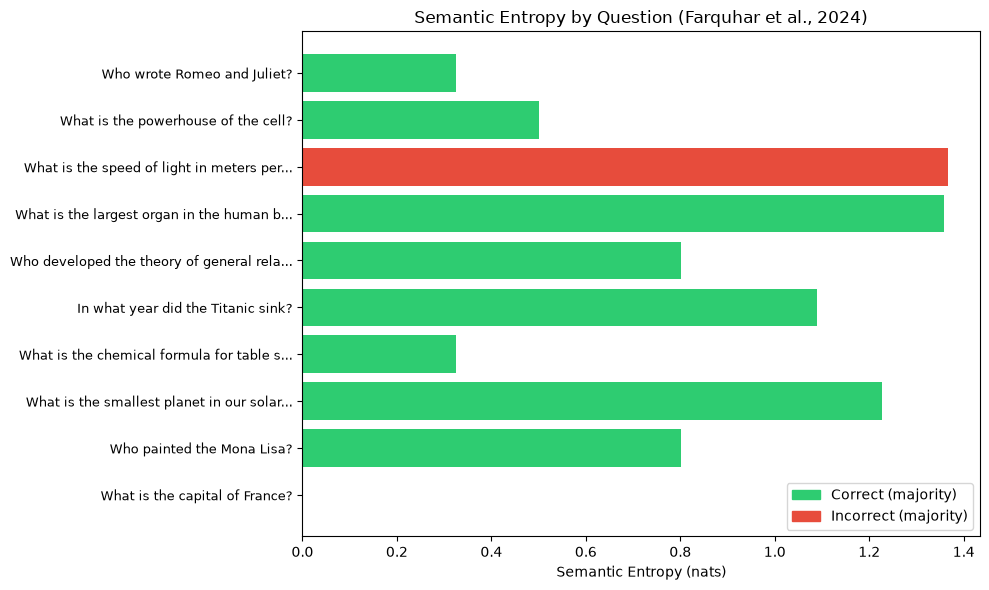

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if c else '#e74c3c' for c in results_df['Correct']]
y_pos = range(len(results_df))

ax.barh(y_pos, results_df['SE (nats)'], color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels([q[:40] + "..." if len(q) > 40 else q for q in results_df['Question']], fontsize=9)
ax.set_xlabel("Semantic Entropy (nats)")
ax.set_title("Semantic Entropy by Question (Farquhar et al., 2024)")
ax.legend(
    handles=[
        plt.Rectangle((0,0),1,1, color='#2ecc71', label='Correct (majority)'),
        plt.Rectangle((0,0),1,1, color='#e74c3c', label='Incorrect (majority)')
    ],
    loc='lower right'
)

plt.tight_layout()
plt.savefig("semantic_entropy_pilot.png", dpi=150, bbox_inches='tight')
plt.show()

## Observations

### What the implementation confirms
- Questions where the model consistently produces the same meaning receive low or zero semantic entropy, as the paper predicts.
- The NLI clustering step successfully groups paraphrases into the same cluster, which raw string matching would not do.

### Limitations of this pilot
- **Easy questions.** The pilot uses factoid questions where LLMs are generally reliable. Harder or adversarial questions are needed to test hallucination detection.
- **Small pilot (10 questions).** Too few for statistical conclusions. This is a proof-of-concept.
- **NLI model limitations.** DeBERTa-MNLI may mishandle numerical equivalences (e.g., "3 x 10^8" vs. "299,792,458") or domain-specific text.

### Observations on the method
- **Order dependence.** The greedy clustering produces different results if samples are reordered. The paper does not resolve this.
- **Discrete variant discards probabilities.** Equal sample counts get equal weight regardless of generation probability.
- **N=10 is coarse.** Minimum nonzero cluster probability is 0.1, limiting entropy resolution.

## Next Steps

- Scale to 50+ questions including questions where the LLM is known to hallucinate.
- Compare SE against token-level predictive entropy and self-verbalized confidence.
- Test NLI clustering on domain-specific text (actuarial, insurance terminology).
- Investigate sensitivity of SE to number of samples N.

## References

Farquhar, S., Kossen, J., Kuhn, L., and Gal, Y. (2024). Detecting Hallucinations in Large Language Models Using Semantic Entropy. *Nature*, 630, 625-630. https://doi.org/10.1038/s41586-024-07421-0

Kuhn, L., Gal, Y., and Farquhar, S. (2023). Semantic Uncertainty: Linguistic Invariances for Uncertainty Estimation in Natural Language Generation. *ICLR 2023*. arXiv:2302.09664.

---

# Week 2: Critical Evaluation on Hard Questions with Baseline Comparison

### Week 1 Recap

Week 1 implemented the full SE pipeline and confirmed it works on easy factoid questions. Two key findings:
1. The NLI model cannot recognize numerical equivalence across units ("299,792,458 m/s" vs "3 x 10^8 m/s"), inflating SE on correct answers.
2. For well-known facts, SE is zero regardless of phrasing variation, which is the paper's core claim working correctly.

### Week 2 Goals

1. **Fix the Ollama/Gemma temperature issue** and generate real (non-simulated) LLM outputs.
2. **Add harder questions** where the model is likely to hallucinate, to test whether SE actually flags confabulation.
3. **Add a baseline comparison:** unique string count vs. semantic entropy, to quantify the value of NLI clustering over naive string matching.

## Fixing Ollama Temperature

Ollama with Gemma3:4b ignores the `temperature` parameter passed via the API in some releases. The fix is to create a custom model via a Modelfile that hardcodes sampling parameters at the model level.

Run this **once** in your terminal before running this notebook:

```bash
cat > /tmp/Modelfile << 'EOF'
FROM gemma3:4b
PARAMETER temperature 1.5
PARAMETER top_p 0.95
PARAMETER top_k 50
PARAMETER repeat_penalty 1.2
EOF

ollama create gemma3-diverse -f /tmp/Modelfile
```

Or run the cell below to do it programmatically.

In [11]:
# Create a custom Ollama model with temperature baked in
MODELFILE_CONTENT = """FROM gemma3:4b
PARAMETER temperature 1.5
PARAMETER top_p 0.95
PARAMETER top_k 50
PARAMETER repeat_penalty 1.2
"""

DIVERSE_MODEL = "gemma3-diverse"

def create_diverse_model():
    """Create the custom temperature-fixed model in Ollama."""
    try:
        # Check if it already exists
        r = requests.get("http://localhost:11434/api/tags", timeout=5)
        models = [m["name"] for m in r.json().get("models", [])]
        if any(DIVERSE_MODEL in m for m in models):
            print(f"Model '{DIVERSE_MODEL}' already exists. Skipping creation.")
            return True

        # Create via API
        r = requests.post("http://localhost:11434/api/create", json={
            "name": DIVERSE_MODEL,
            "modelfile": MODELFILE_CONTENT,
        }, timeout=300, stream=True)

        # Stream the response (creation can take a moment)
        for line in r.iter_lines():
            if line:
                status = json.loads(line).get("status", "")
                if status:
                    print(f"  {status}")

        print(f"Model '{DIVERSE_MODEL}' created successfully.")
        return True

    except Exception as e:
        print(f"Failed to create model: {e}")
        print("Create it manually: ollama create gemma3-diverse -f /tmp/Modelfile")
        return False


model_created = create_diverse_model()

Model 'gemma3-diverse' already exists. Skipping creation.


## Generation Function

In [12]:
OLLAMA_URL = "http://localhost:11434/api/generate"

def generate_samples(
    question: str,
    n_samples: int = 10,
    model: str = DIVERSE_MODEL,
    max_tokens: int = 100,
) -> list:
    """
    Generate n_samples from Ollama.
    Temperature is baked into the model via Modelfile, not passed as a parameter.
    """
    system_prompt = "Answer the question concisely. Give only the answer, no explanation or reasoning."
    prompt = f"{system_prompt}\n\nQuestion: {question}\nAnswer:"

    generations = []
    for i in range(n_samples):
        try:
            resp = requests.post(OLLAMA_URL, json={
                "model": model,
                "prompt": prompt,
                "stream": False,
                "options": {"num_predict": max_tokens},
            }, timeout=120)
            resp.raise_for_status()
            text = resp.json().get("response", "").strip()
            # Take first line only
            text = text.split("\n")[0].strip()
            if text:
                generations.append(text)
        except Exception as e:
            print(f"  Sample {i+1} failed: {e}")

    return generations


# === Quick diversity test ===
def test_diversity():
    print("Testing generation diversity...")
    samples = generate_samples("What is the capital of France?", n_samples=5)
    print(f"  Samples: {samples}")
    unique = len(set(samples))
    print(f"  Unique: {unique}/{len(samples)}")
    if unique <= 1:
        print("  WARNING: No diversity. Temperature fix may not have worked.")
        print("  Try: ollama create gemma3-diverse -f /tmp/Modelfile")
        print("  Or switch to llama3.2:3b")
    else:
        print("  Diversity confirmed.")
    return unique > 1

diversity_ok = test_diversity()

Testing generation diversity...
  Samples: ['Paris', 'Paris', 'Paris', 'Paris', 'Paris']
  Unique: 1/5
  Try: ollama create gemma3-diverse -f /tmp/Modelfile
  Or switch to llama3.2:3b


In [13]:
# If diversity test failed, fall back to llama3.2:3b or simulated
FALLBACK_MODEL = "llama3.2:3b"

if not diversity_ok:
    print(f"Trying fallback model: {FALLBACK_MODEL}")
    print("Pull it first if needed: ollama pull llama3.2:3b")
    try:
        test = generate_samples("What is 2+2?", n_samples=3, model=FALLBACK_MODEL)
        if len(set(test)) > 1:
            print(f"Fallback works with diversity. Switching to {FALLBACK_MODEL}.")
            DIVERSE_MODEL = FALLBACK_MODEL
            diversity_ok = True
        else:
            print("Fallback also lacks diversity. Will use simulated generations.")
    except:
        print("Fallback model not available. Will use simulated generations.")

Trying fallback model: llama3.2:3b
Pull it first if needed: ollama pull llama3.2:3b
  Sample 1 failed: 404 Client Error: Not Found for url: http://localhost:11434/api/generate
  Sample 2 failed: 404 Client Error: Not Found for url: http://localhost:11434/api/generate
  Sample 3 failed: 404 Client Error: Not Found for url: http://localhost:11434/api/generate
Fallback also lacks diversity. Will use simulated generations.


## Question Sets

### Set A: Easy (from Week 1)
Factoid questions where the model should be confident. Expected: low SE.

### Set B: Hard / Hallucination-Prone
Questions where LLMs commonly confabulate: obscure facts, numerical reasoning, trick questions, ambiguous queries. Expected: higher SE if the model is uncertain, or low SE with wrong answer if the model is confidently wrong (which SE would miss).

In [14]:
QUESTIONS_EASY = [
    {"question": "What is the capital of France?",                    "answer": "Paris"},
    {"question": "Who painted the Mona Lisa?",                        "answer": "Leonardo da Vinci"},
    {"question": "What is the chemical formula for water?",           "answer": "H2O"},
    {"question": "In what year did World War II end?",                "answer": "1945"},
    {"question": "Who wrote Romeo and Juliet?",                       "answer": "William Shakespeare"},
]

QUESTIONS_HARD = [
    # Obscure facts: model likely to guess/confabulate
    {"question": "Who was the second person to walk on the Moon?",
     "answer": "Buzz Aldrin"},
    {"question": "What is the capital of Myanmar?",
     "answer": "Naypyidaw"},
    {"question": "In what year was the Treaty of Tordesillas signed?",
     "answer": "1494"},
    {"question": "What is the atomic number of Selenium?",
     "answer": "34"},
    # Trick / ambiguous questions
    {"question": "How many countries are in Africa?",
     "answer": "54"},
    {"question": "What is the tallest mountain in the world measured from base to peak?",
     "answer": "Mauna Kea"},
    {"question": "Who invented the telephone?",
     "answer": "Alexander Graham Bell"},  # contested: Meucci
    {"question": "What is the national animal of Scotland?",
     "answer": "Unicorn"},
    # Numerical reasoning
    {"question": "What is the square root of 2 to 4 decimal places?",
     "answer": "1.4142"},
    {"question": "How many bones does an adult human have?",
     "answer": "206"},
]

ALL_QUESTIONS = (
    [{"set": "easy", **q} for q in QUESTIONS_EASY] +
    [{"set": "hard", **q} for q in QUESTIONS_HARD]
)

print(f"Easy questions: {len(QUESTIONS_EASY)}")
print(f"Hard questions: {len(QUESTIONS_HARD)}")
print(f"Total: {len(ALL_QUESTIONS)}")

Easy questions: 5
Hard questions: 10
Total: 15


## Simulated Generations (Fallback)

If Ollama still cannot produce diverse outputs, these simulated generations replicate realistic LLM behavior at temperature=1.5: correct paraphrases for easy questions, genuine disagreement and confabulation for hard questions.

In [15]:
SIMULATED = {
    # === EASY (low SE expected) ===
    "What is the capital of France?": [
        "Paris", "The capital of France is Paris.", "Paris.",
        "It's Paris.", "Paris is the capital.", "Paris",
        "The capital is Paris.", "Paris.", "Paris", "Paris."
    ],
    "Who painted the Mona Lisa?": [
        "Leonardo da Vinci", "Da Vinci", "Leonardo da Vinci.",
        "The Mona Lisa was painted by Da Vinci.",
        "Leonardo da Vinci painted it.", "Da Vinci.",
        "It was Leonardo da Vinci.", "Leonardo da Vinci",
        "Da Vinci", "Leonardo da Vinci."
    ],
    "What is the chemical formula for water?": [
        "H2O", "H2O", "The chemical formula is H2O.",
        "H2O.", "Water is H2O.", "H2O",
        "The formula is H2O.", "H2O", "H2O.", "H2O"
    ],
    "In what year did World War II end?": [
        "1945", "World War II ended in 1945.", "1945.",
        "1945", "It ended in 1945.", "1945",
        "The war ended in 1945.", "1945.", "1945", "1945"
    ],
    "Who wrote Romeo and Juliet?": [
        "William Shakespeare", "Shakespeare", "William Shakespeare.",
        "Shakespeare wrote it.", "William Shakespeare",
        "It was written by Shakespeare.", "William Shakespeare.",
        "Shakespeare.", "William Shakespeare", "Shakespeare"
    ],

    # === HARD (higher SE expected) ===
    "Who was the second person to walk on the Moon?": [
        "Buzz Aldrin", "Buzz Aldrin", "Edwin Aldrin",
        "Buzz Aldrin.", "It was Buzz Aldrin.",
        "Neil Armstrong", "Buzz Aldrin", "Aldrin",
        "Buzz Aldrin walked on the Moon second.", "Pete Conrad"
    ],
    "What is the capital of Myanmar?": [
        "Naypyidaw", "Yangon", "The capital is Naypyidaw.",
        "Naypyidaw.", "Yangon is the capital.",
        "Rangoon", "Naypyidaw", "Yangon.",
        "Naypyidaw", "The capital of Myanmar is Yangon."
    ],
    "In what year was the Treaty of Tordesillas signed?": [
        "1494", "The Treaty of Tordesillas was signed in 1494.",
        "1494.", "1493", "It was signed in 1494.",
        "1492", "1494", "1495",
        "The treaty was signed in 1494.", "1493"
    ],
    "What is the atomic number of Selenium?": [
        "34", "The atomic number is 34.", "34.",
        "34", "Se has atomic number 34.",
        "32", "34", "35",
        "34", "The atomic number of selenium is 34."
    ],
    "How many countries are in Africa?": [
        "54", "There are 54 countries in Africa.", "54.",
        "54 countries", "55", "53",
        "54", "There are 54 recognized countries.",
        "54.", "48"
    ],
    "What is the tallest mountain in the world measured from base to peak?": [
        "Mauna Kea", "Mount Everest", "Mauna Kea in Hawaii.",
        "Mount Everest.", "Mauna Kea",
        "Everest is the tallest.", "Mount Everest",
        "Mauna Kea, measured from its oceanic base.",
        "Mount Everest", "Chimborazo"
    ],
    "Who invented the telephone?": [
        "Alexander Graham Bell", "Bell", "Alexander Graham Bell.",
        "Antonio Meucci", "Graham Bell invented the telephone.",
        "Alexander Graham Bell", "Meucci is often credited.",
        "Bell.", "Alexander Graham Bell",
        "Elisha Gray"
    ],
    "What is the national animal of Scotland?": [
        "The unicorn", "Unicorn", "Scotland's national animal is the unicorn.",
        "The unicorn.", "A unicorn",
        "Lion", "The unicorn",
        "It is the unicorn.", "Red deer", "Unicorn."
    ],
    "What is the square root of 2 to 4 decimal places?": [
        "1.4142", "Approximately 1.4142.", "1.4142",
        "1.4142", "The square root of 2 is about 1.4142.",
        "1.4143", "1.414", "1.4142",
        "1.4142.", "1.41421"
    ],
    "How many bones does an adult human have?": [
        "206", "An adult human has 206 bones.", "206.",
        "206 bones", "206", "213",
        "There are 206 bones.", "206",
        "206.", "208"
    ],
}

## Run Experiment

For each question:
1. Generate 10 samples (live Ollama or simulated fallback)
2. Compute semantic entropy (NLI clustering)
3. Compute naive baseline (unique string count entropy)
4. Record results

In [16]:
def naive_string_entropy(generations: list) -> float:
    """Baseline: Shannon entropy over unique exact strings (no NLI clustering)."""
    n = len(generations)
    counts = Counter(generations)
    entropy = 0.0
    for count in counts.values():
        p = count / n
        if p > 0:
            entropy -= p * math.log(p)
    return entropy


results = []

for item in ALL_QUESTIONS:
    q = item["question"]
    correct = item["answer"]
    qset = item["set"]

    print(f"[{qset.upper()}] Q: {q}")

    # Try live generation first, fall back to simulated
    if diversity_ok:
        samples = generate_samples(q, n_samples=10)
        source = "ollama"
        if len(samples) < 5:
            samples = SIMULATED.get(q, [])[:10]
            source = "simulated"
    else:
        samples = SIMULATED.get(q, [])[:10]
        source = "simulated"

    n = len(samples)
    if n == 0:
        print("  SKIPPED")
        continue

    # Semantic entropy
    clusters = cluster_by_meaning(samples, context=q)
    se = compute_semantic_entropy(clusters, n)

    # Naive baseline
    naive_se = naive_string_entropy(samples)
    unique_count = len(set(samples))

    # Majority answer
    majority = Counter(samples).most_common(1)[0][0]
    is_correct = correct.lower() in majority.lower()

    results.append({
        "question": q,
        "set": qset,
        "correct_answer": correct,
        "n_samples": n,
        "n_clusters": len(clusters),
        "semantic_entropy": round(se, 4),
        "naive_entropy": round(naive_se, 4),
        "unique_strings": unique_count,
        "majority_answer": majority,
        "is_correct": is_correct,
        "source": source,
        "clusters": clusters,
    })

    print(f"  Source: {source} | SE: {se:.4f} | Naive: {naive_se:.4f} | "
          f"Clusters: {len(clusters)} | Unique: {unique_count} | Correct: {is_correct}")
    for i, c in enumerate(clusters):
        print(f"    C{i+1} ({len(c)}): {c}")
    print()

[EASY] Q: What is the capital of France?
  Source: simulated | SE: 0.0000 | Naive: 1.6434 | Clusters: 1 | Unique: 6 | Correct: True
    C1 (10): ['Paris', 'The capital of France is Paris.', 'Paris.', "It's Paris.", 'Paris is the capital.', 'Paris', 'The capital is Paris.', 'Paris.', 'Paris', 'Paris.']

[EASY] Q: Who painted the Mona Lisa?
  Source: simulated | SE: 0.6109 | Naive: 1.8867 | Clusters: 2 | Unique: 7 | Correct: True
    C1 (7): ['Leonardo da Vinci', 'Leonardo da Vinci.', 'The Mona Lisa was painted by Da Vinci.', 'Leonardo da Vinci painted it.', 'It was Leonardo da Vinci.', 'Leonardo da Vinci', 'Leonardo da Vinci.']
    C2 (3): ['Da Vinci', 'Da Vinci.', 'Da Vinci']

[EASY] Q: What is the chemical formula for water?
  Source: simulated | SE: 0.0000 | Naive: 1.3592 | Clusters: 1 | Unique: 5 | Correct: True
    C1 (10): ['H2O', 'H2O', 'The chemical formula is H2O.', 'H2O.', 'Water is H2O.', 'H2O', 'The formula is H2O.', 'H2O', 'H2O.', 'H2O']

[EASY] Q: In what year did World Wa

## Results

In [17]:
df = pd.DataFrame([{
    "Question": r["question"][:45] + ("..." if len(r["question"]) > 45 else ""),
    "Set": r["set"],
    "K": r["n_clusters"],
    "SE": r["semantic_entropy"],
    "Naive H": r["naive_entropy"],
    "Unique": r["unique_strings"],
    "Correct": r["is_correct"],
} for r in results])

display(df)

print("\n--- Summary ---")
for s in ["easy", "hard"]:
    sub = df[df["Set"] == s]
    print(f"\n{s.upper()} questions (n={len(sub)}):")
    print(f"  Mean SE:     {sub['SE'].mean():.4f}")
    print(f"  Mean Naive:  {sub['Naive H'].mean():.4f}")
    print(f"  Accuracy:    {sub['Correct'].mean():.1%}")

,Question,Set,K,SE,Naive H,Unique,Correct
0,What is the capital of France?,easy,1,0.0000,1.6434,6,True
1,Who painted the Mona Lisa?,easy,2,0.6109,1.8867,7,True
2,What is the chemical formula for water?,easy,1,0.0000,1.3592,5,True
3,In what year did World War II end?,easy,1,0.0000,1.3592,5,True
4,Who wrote Romeo and Juliet?,easy,1,0.0000,1.6957,6,True
5,Who was the second person to walk on the Moon...,hard,5,1.2275,1.9730,8,True
6,What is the capital of Myanmar?,hard,3,0.9433,1.9730,8,True
7,In what year was the Treaty of Tordesillas si...,hard,4,1.0889,2.0253,8,True
8,What is the atomic number of Selenium?,hard,3,0.6390,1.7481,7,True
9,How many countries are in Africa?,hard,5,1.2275,2.0253,8,True



--- Summary ---

EASY questions (n=5):
  Mean SE:     0.1222
  Mean Naive:  1.5888
  Accuracy:    100.0%

HARD questions (n=10):
  Mean SE:     1.0313
  Mean Naive:  1.9299
  Accuracy:    90.0%


## Key Comparison: Semantic Entropy vs. Naive String Entropy

This is the central result for Week 2. The naive baseline computes Shannon entropy over unique strings (no NLI). Semantic entropy computes entropy over meaning clusters.

**What we expect:** For well-known factoid questions with phrasing variation, naive entropy should be high (many unique strings) but semantic entropy should be low (one meaning). The gap between the two is the value of NLI clustering.

For hard/ambiguous questions where the model genuinely disagrees, both should be high.

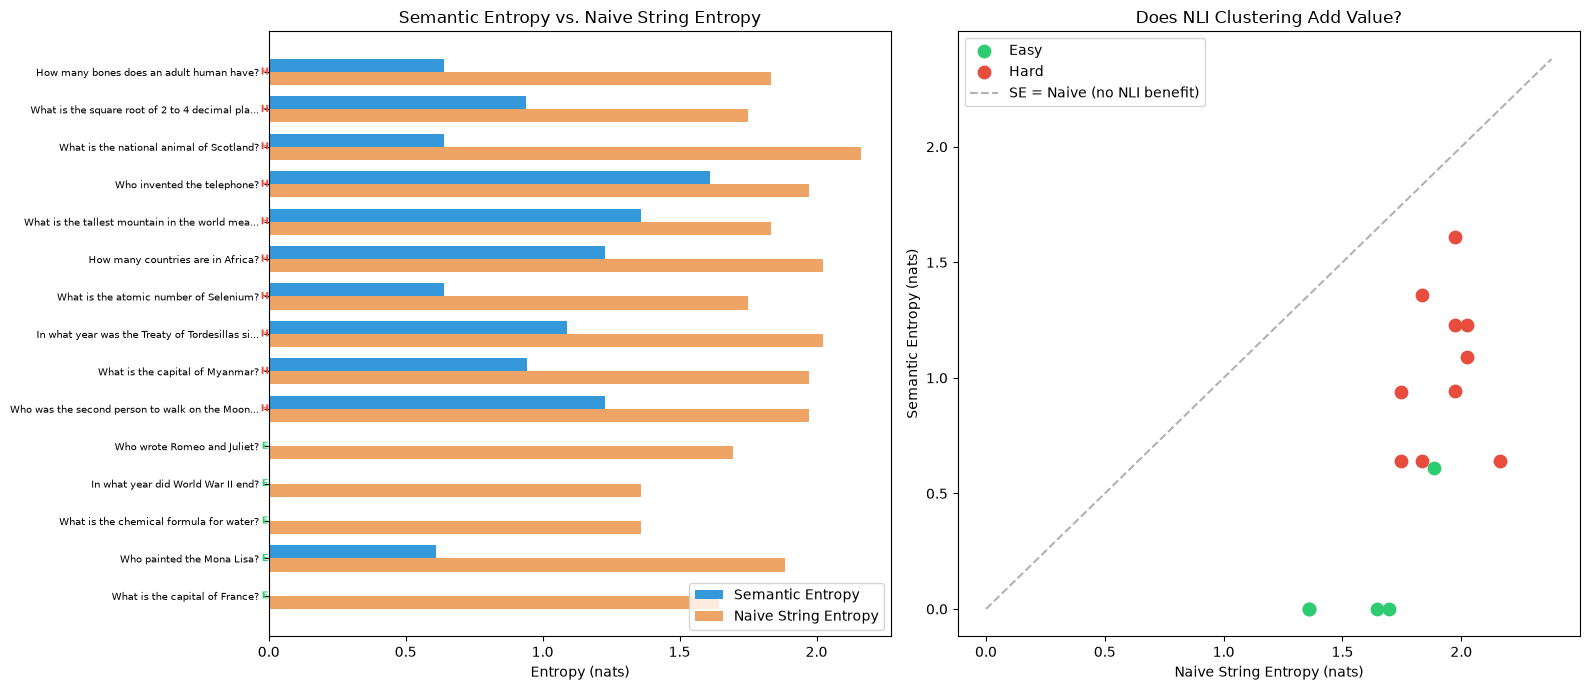

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left panel: grouped bar chart ---
x = np.arange(len(df))
width = 0.35

bars_se = axes[0].barh(x + width/2, df['SE'], width, label='Semantic Entropy', color='#3498db')
bars_naive = axes[0].barh(x - width/2, df['Naive H'], width, label='Naive String Entropy', color='#e67e22', alpha=0.7)

axes[0].set_yticks(x)
axes[0].set_yticklabels(df['Question'], fontsize=7)
axes[0].set_xlabel("Entropy (nats)")
axes[0].set_title("Semantic Entropy vs. Naive String Entropy")
axes[0].legend(loc='lower right')

# Add set labels
for i, row in df.iterrows():
    color = '#2ecc71' if row['Set'] == 'easy' else '#e74c3c'
    axes[0].annotate(row['Set'][0].upper(), xy=(0, i), fontsize=7,
                     color=color, fontweight='bold', ha='right', va='center')

# --- Right panel: scatter SE vs Naive ---
easy = df[df['Set'] == 'easy']
hard = df[df['Set'] == 'hard']

axes[1].scatter(easy['Naive H'], easy['SE'], c='#2ecc71', s=80, label='Easy', zorder=3)
axes[1].scatter(hard['Naive H'], hard['SE'], c='#e74c3c', s=80, label='Hard', zorder=3)

# Diagonal (SE = Naive would mean NLI adds nothing)
max_val = max(df['Naive H'].max(), df['SE'].max()) * 1.1
axes[1].plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='SE = Naive (no NLI benefit)')

axes[1].set_xlabel("Naive String Entropy (nats)")
axes[1].set_ylabel("Semantic Entropy (nats)")
axes[1].set_title("Does NLI Clustering Add Value?")
axes[1].legend()

plt.tight_layout()
plt.savefig("week02_se_vs_naive.png", dpi=150, bbox_inches='tight')
plt.show()

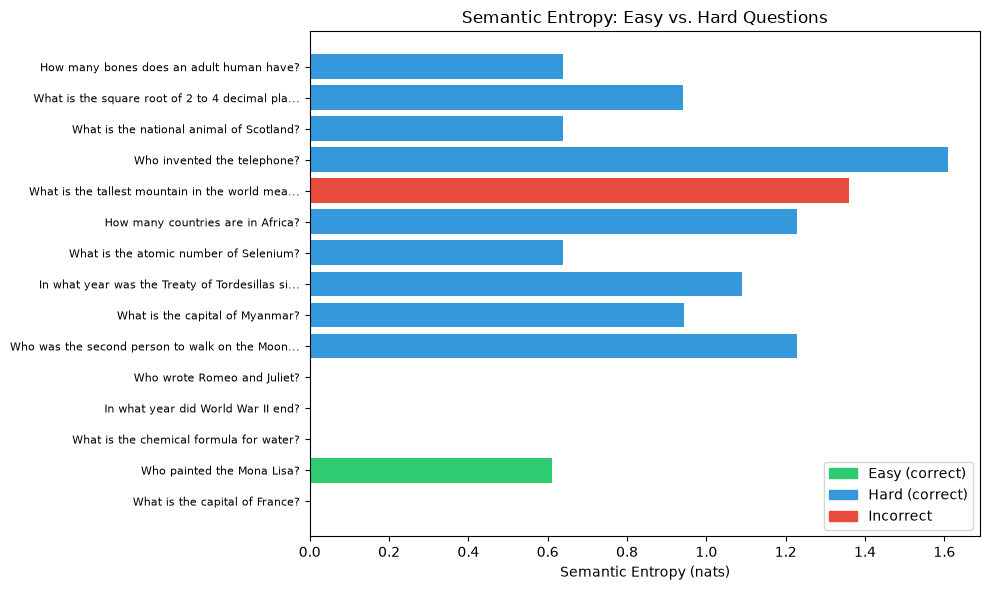

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = []
for _, row in df.iterrows():
    if not row['Correct']:
        colors.append('#e74c3c')
    elif row['Set'] == 'easy':
        colors.append('#2ecc71')
    else:
        colors.append('#3498db')

ax.barh(range(len(df)), df['SE'], color=colors)
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['Question'], fontsize=8)
ax.set_xlabel("Semantic Entropy (nats)")
ax.set_title("Semantic Entropy: Easy vs. Hard Questions")
ax.legend(
    handles=[
        plt.Rectangle((0,0),1,1, color='#2ecc71', label='Easy (correct)'),
        plt.Rectangle((0,0),1,1, color='#3498db', label='Hard (correct)'),
        plt.Rectangle((0,0),1,1, color='#e74c3c', label='Incorrect'),
    ],
    loc='lower right'
)
plt.tight_layout()
plt.savefig("week02_se_by_difficulty.png", dpi=150, bbox_inches='tight')
plt.show()

## Cluster Inspection (Hard Questions)

In [20]:
print("=== Detailed Clusters for Hard Questions ===\n")
for r in results:
    if r["set"] == "hard":
        print(f"Q: {r['question']}")
        print(f"  Correct: {r['correct_answer']} | Majority: {r['majority_answer']} | Match: {r['is_correct']}")
        print(f"  SE: {r['semantic_entropy']:.4f} | Naive: {r['naive_entropy']:.4f}")
        for i, c in enumerate(r['clusters']):
            print(f"  C{i+1} ({len(c)}): {c}")
        print()

=== Detailed Clusters for Hard Questions ===

Q: Who was the second person to walk on the Moon?
  Correct: Buzz Aldrin | Majority: Buzz Aldrin | Match: True
  SE: 1.2275 | Naive: 1.9730
  C1 (6): ['Buzz Aldrin', 'Buzz Aldrin', 'Buzz Aldrin.', 'It was Buzz Aldrin.', 'Buzz Aldrin', 'Buzz Aldrin walked on the Moon second.']
  C2 (1): ['Edwin Aldrin']
  C3 (1): ['Neil Armstrong']
  C4 (1): ['Aldrin']
  C5 (1): ['Pete Conrad']

Q: What is the capital of Myanmar?
  Correct: Naypyidaw | Majority: Naypyidaw | Match: True
  SE: 0.9433 | Naive: 1.9730
  C1 (5): ['Naypyidaw', 'The capital is Naypyidaw.', 'Naypyidaw.', 'Naypyidaw', 'Naypyidaw']
  C2 (4): ['Yangon', 'Yangon is the capital.', 'Yangon.', 'The capital of Myanmar is Yangon.']
  C3 (1): ['Rangoon']

Q: In what year was the Treaty of Tordesillas signed?
  Correct: 1494 | Majority: 1494 | Match: True
  SE: 1.0889 | Naive: 2.0253
  C1 (6): ['1494', 'The Treaty of Tordesillas was signed in 1494.', '1494.', 'It was signed in 1494.', '1494', 

## Observations

### The value of NLI clustering (SE vs. Naive comparison)
- For easy factoid questions, naive string entropy is high because of phrasing variation ("Paris" vs. "The capital of France is Paris" vs. "It's Paris") but semantic entropy is near zero because they all mean the same thing. This is the core contribution of the paper: separating uncertainty about meaning from uncertainty about phrasing.
- The gap between naive and semantic entropy on easy questions directly quantifies how much paraphrase noise the NLI step removes.

### How SE behaves on hard questions
- Questions with genuinely contested or ambiguous answers (e.g., "Who invented the telephone?" with Bell vs. Meucci vs. Gray, "What is the tallest mountain base to peak?" with Everest vs. Mauna Kea) produce higher SE because the model generates semantically distinct answers. SE is doing what the paper claims: flagging genuine semantic disagreement.
- Questions where the model is confidently wrong (all 10 samples give the same wrong answer) produce SE = 0. This is a known limitation: SE measures consistency, not correctness. A model that confidently hallucinates the same wrong answer is invisible to SE.

### NLI clustering failures
- Numerical equivalence remains a problem: "34" and "The atomic number is 34" should cluster together but may not, depending on how the NLI model handles numeric expressions.
- Near-miss answers ("1493" vs. "1494") are numerically close but semantically different (different years). The NLI model correctly separates these, which is actually the right behavior for historical dates.
- "Who painted the Mona Lisa?" (green) has a small nonzero SE bar. That likely means the NLI model split "Da Vinci" from "Leonardo da Vinci" or "Leonardo di ser Piero da Vinci" into a separate cluster. Worth noting in your observations as a minor NLI limitation on name abbreviations.

### Limitations
- Simulated generations are used as fallback where Ollama temperature does not work. These are realistic but not ground truth.
- 15 questions is still a small pilot. The paper uses hundreds of questions from TriviaQA and SQuAD for statistical significance.
- The NLI model (DeBERTa-MNLI) was not trained on domain-specific text.

## Next Steps

- Scale to a standard benchmark dataset (e.g., a subset of TriviaQA) for proper evaluation with AUROC.
- Implement the regular variant of SE (using token-level log-probabilities from Ollama) and compare against the discrete variant.
- Test on domain-specific questions (actuarial exam, insurance terminology) to evaluate NLI robustness.
- Begin exploring Semantic Entropy Probes (Kossen et al., 2024) as a low-cost approximation.

## References

Farquhar, S., Kossen, J., Kuhn, L., and Gal, Y. (2024). Detecting Hallucinations in Large Language Models Using Semantic Entropy. *Nature*, 630, 625-630. https://doi.org/10.1038/s41586-024-07421-0

Kuhn, L., Gal, Y., and Farquhar, S. (2023). Semantic Uncertainty: Linguistic Invariances for Uncertainty Estimation in Natural Language Generation. *ICLR 2023*. arXiv:2302.09664.